In [59]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg') 
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [ ]:
#loading
file_path = 'moviesTMBD.csv'
df = pd.read_csv(file_path, encoding='utf-8', delimiter=',')

In [ ]:
#exploring
print("head:")
print(df.head(10))
print("info:")
print(df.info())
print("describe:")
print(df.describe())

head:
   Unnamed: 0       id                        title  popularity  adult  \
0           0  1007757                      Swapped    327.5134  False   
1           1      278     The Shawshank Redemption     65.3308  False   
2           2      238                The Godfather     47.2346  False   
3           3   687163            Project Hail Mary    422.0199  False   
4           4      240        The Godfather Part II     27.6763  False   
5           5      424             Schindler's List     35.8510  False   
6           6      389                 12 Angry Men     22.8937  False   
7           7  1330021  Remarkably Bright Creatures     96.5828  False   
8           8      129                Spirited Away     32.2851  False   
9           9      155              The Dark Knight     45.5176  False   

  original_language                                           overview  \
0                en  A small woodland creature and a majestic bird,...   
1                en  Imprisoned

In [94]:
#cleaning
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


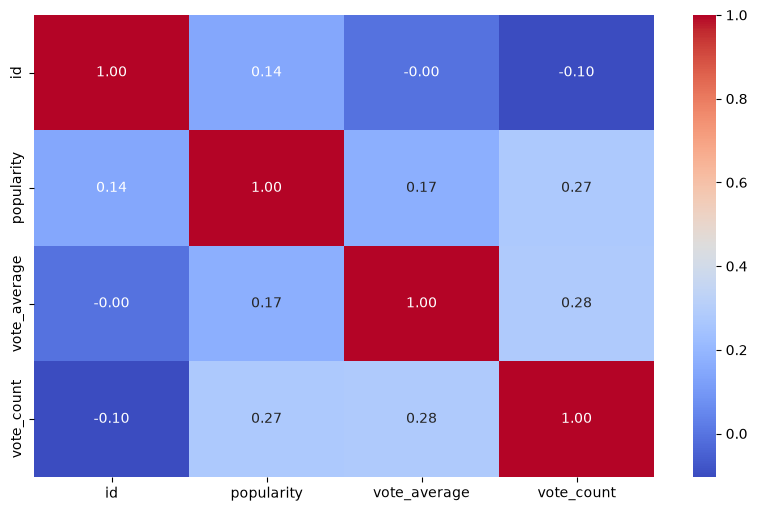

In [ ]:
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >3:
    plt.figure(figsize=(10,6))
    corr = num_df.corr()
    sns.heatmap(corr,annot=True,cmap='coolwarm', fmt=".2f")
    plt.show()


AttributeError: QuadMesh.set() got an unexpected keyword argument 'scatter_kws'

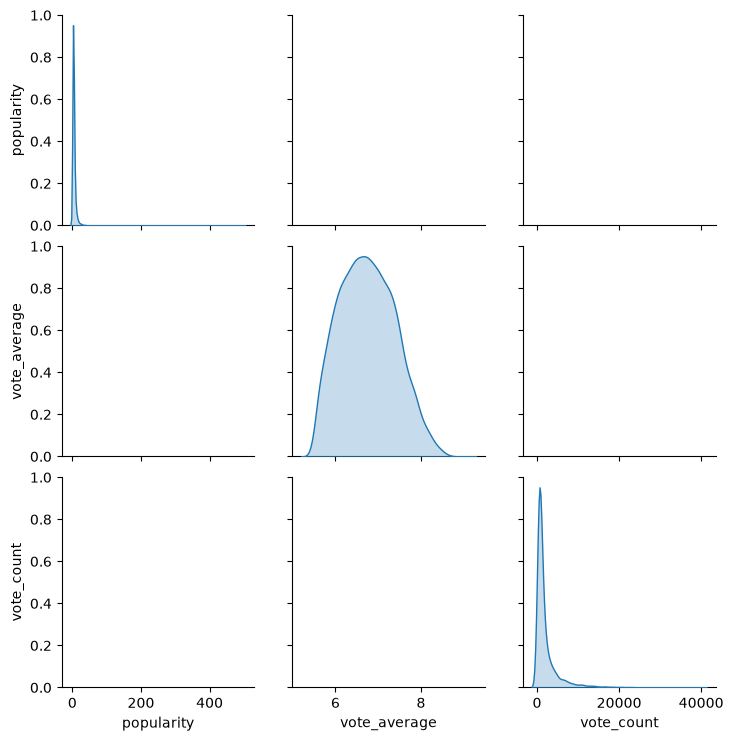

In [ ]:

g = sns.pairplot(df[['popularity', 'vote_average', 'vote_count']], kind='reg', diag_kind='kde',
                     plot_kws={'scatter_kws': {'alpha': 0.2, 's': 10}})
g.figure.suptitle('Relationships between movie metrics', y=1.02)


In [39]:
most_popular= df.nlargest(10,'popularity')[['title','popularity']]
print("Most popular movies:")
print(most_popular)

Most popular movies:
                             title  popularity
17     The Punisher: One Last Kill    499.0857
3                Project Hail Mary    422.0199
499   The Super Mario Galaxy Movie    397.1744
561   The Super Mario Galaxy Movie    397.1744
0                          Swapped    327.5134
1638         The Devil Wears Prada    213.6181
1647         The Devil Wears Prada    213.6181
3405                 Mortal Kombat    180.8740
5181                          Apex    179.6924
5251                          Apex    179.6924


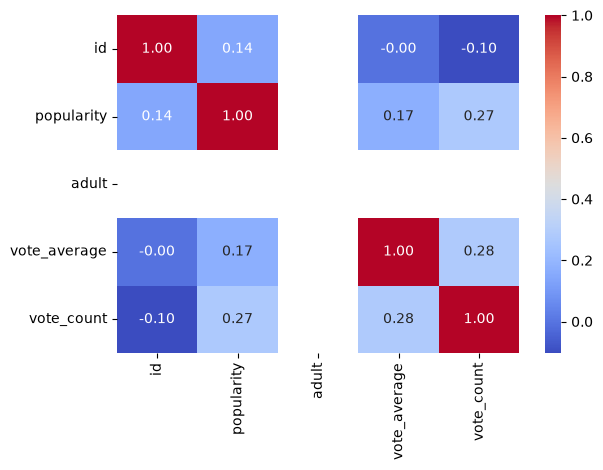

In [49]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True,fmt='.2f')
plt.tight_layout()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 [Text(0, 0, 'en'),
  Text(1, 0, 'fr'),
  Text(2, 0, 'it'),
  Text(3, 0, 'ja'),
  Text(4, 0, 'es'),
  Text(5, 0, 'de'),
  Text(6, 0, 'ko'),
  Text(7, 0, 'cn'),
  Text(8, 0, 'zh'),
  Text(9, 0, 'ru'),
  Text(10, 0, 'hi'),
  Text(11, 0, 'sv'),
  Text(12, 0, 'da'),
  Text(13, 0, 'pt'),
  Text(14, 0, 'no'),
  Text(15, 0, 'pl'),
  Text(16, 0, 'nl'),
  Text(17, 0, 'th'),
  Text(18, 0, 'tr'),
  Text(19, 0, 'fa'),
  Text(20, 0, 'fi'),
  Text(21, 0, 'id'),
  Text(22, 0, 'hu'),
  Text(23, 0, 'te'),
  Text(24, 0, 'el'),
  Text(25, 0, 'cs'),
  Text(26, 0, 'ar'),
  Text(27, 0, 'sr'),
  Text(28, 0, 'uk'),
  Text(29, 0, 'hy'),
  Text(30, 0, 'xx'),
  Text(31, 0, 'ro'),
  Text(32, 0, 'is'),
  Text(33, 0, 'eu'),
  Text(34, 0, 'lv'),
  Text(35, 0, 'bn'),

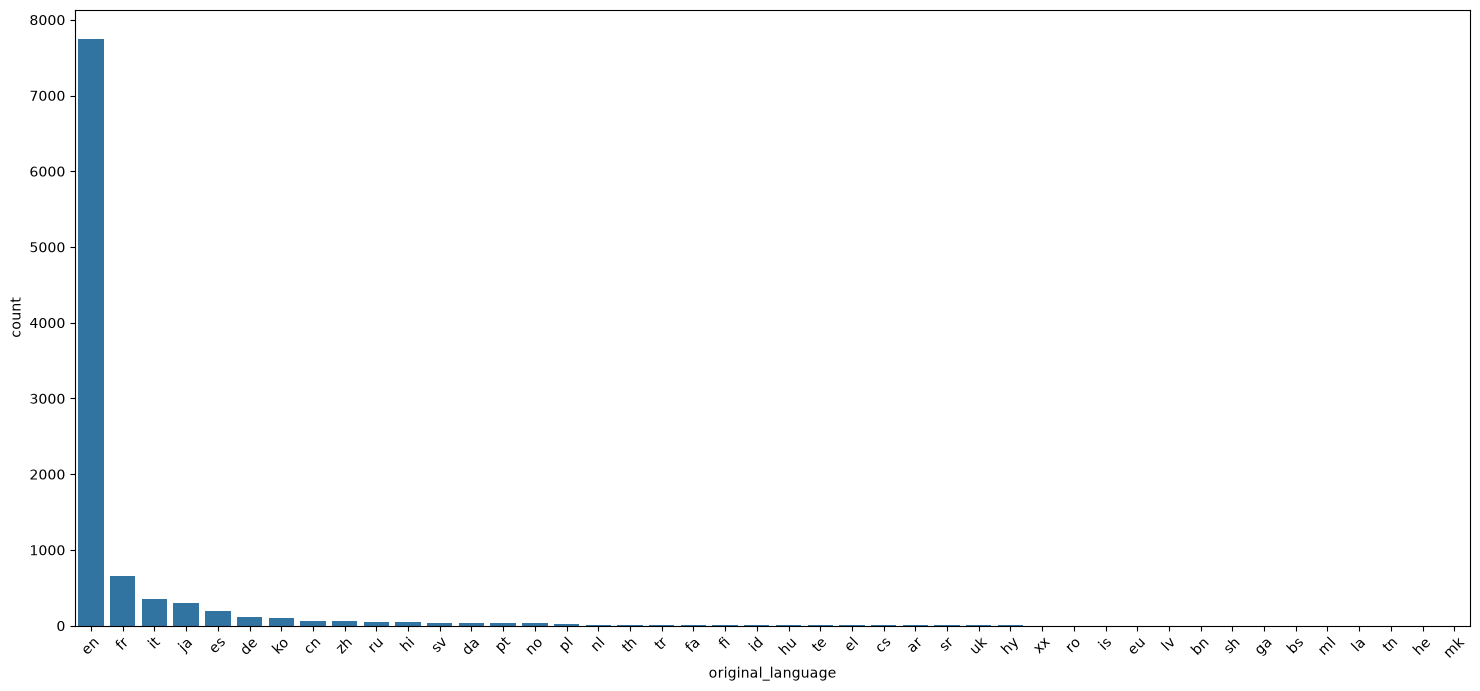

In [53]:
plt.figure(figsize=(18,8))
sns.countplot(x='original_language',data=df,order=df['original_language'].value_counts().index)
plt.xticks(rotation=45)

<Axes: xlabel='original_language'>

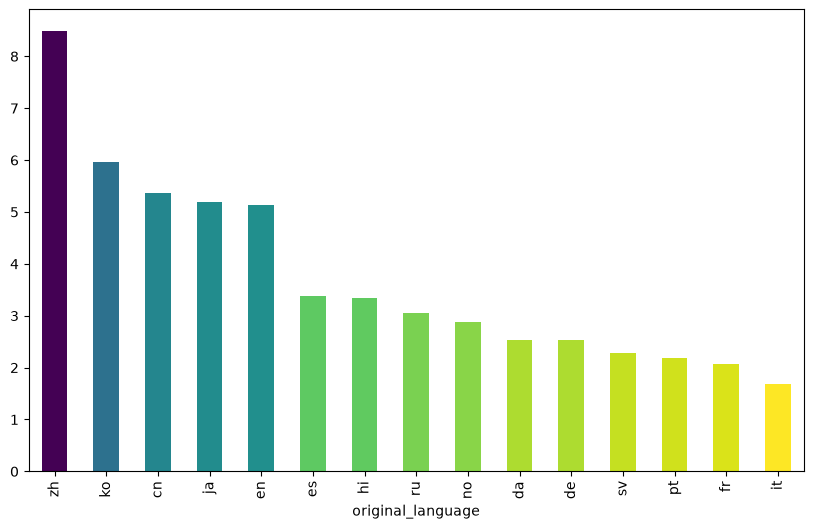

In [68]:
counts = df['original_language'].value_counts()
langs = counts[counts > 30].index
df1=(df[df['original_language'].isin(langs)].groupby('original_language')['popularity'].mean().sort_values(ascending=False))
normalized = mpl.colors.Normalize(vmin=df1.min(), vmax=df1.max())
colors = mpl.cm.viridis_r(normalized(df1.values))
df1.plot(kind='bar',figsize=(10,6),color=colors)

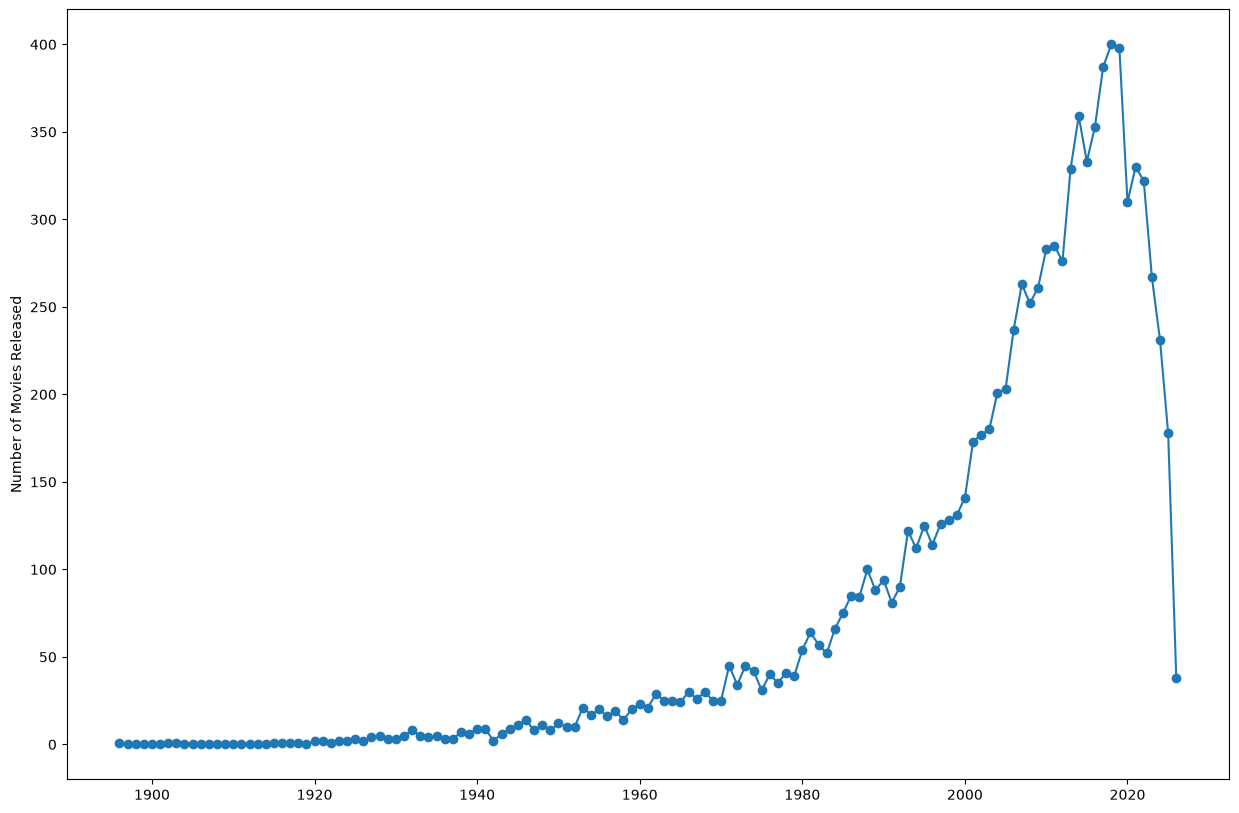

In [85]:
yearly_releases = df.resample('YE', on='release_date').size()
plt.figure(figsize=(15,10))
plt.plot(yearly_releases.index.year, yearly_releases.values, marker='o')
plt.ylabel('Number of Movies Released')
plt.show()


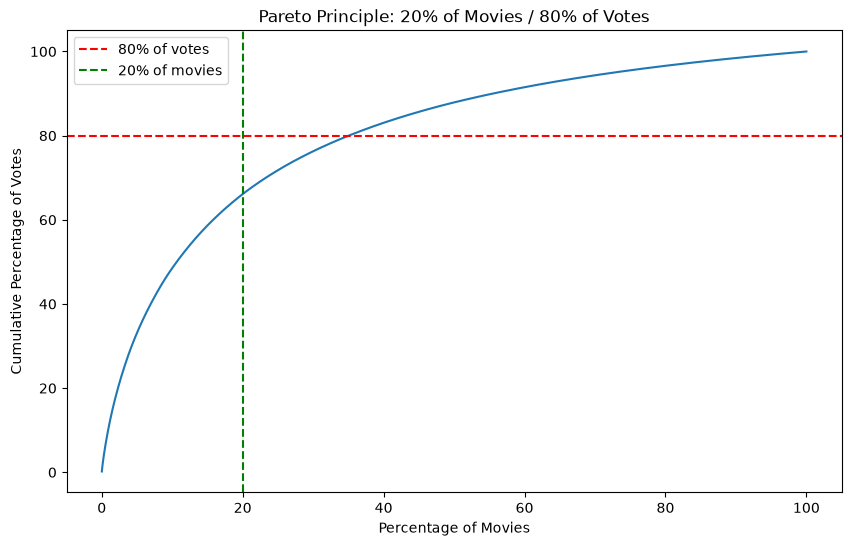

In [87]:
s = df['vote_count'].dropna().sort_values(ascending=False).reset_index(drop=True)
cum_sum_pct=s.cumsum() / s.sum() *100
x_pct = (s.index +1) / len(s) *100
plt.figure(figsize=(10,6))
plt.plot(x_pct, cum_sum_pct)
plt.axhline(80,color='red', linestyle='--',label = "80% of votes")
plt.axvline(20, color='green', linestyle='--', label='20% of movies')
plt.xlabel('Percentage of Movies')
plt.ylabel('Cumulative Percentage of Votes')
plt.title('Pareto Principle: 20% of Movies / 80% of Votes')
plt.legend()
plt.show()
